# Day 7 — Calibration & uncertainty analysis

Point forecasts (MAPE/RMSE/MAE) are only half the story. For real-world decisions you also need
**well-calibrated prediction intervals (PIs)** — an 80% PI should actually contain the truth 80% of the time.

Compare three models:

1. **persistence-24h** — no native PIs. We derive them from **val-set residuals** (residual-based PIs, a simple model-agnostic approach).
2. **LightGBM** — quantile regression at multiple quantile levels.
3. **Chronos-Bolt** — native quantile output at the levels it was trained on (0.1–0.9).

Three views:
- **Coverage** — does the X% PI actually cover X% of actuals?
- **Sharpness** — how wide are the bands? (Narrower is better, given equal coverage.)
- **Reliability plot** — target vs actual coverage across multiple PI levels.

### How to read coverage and sharpness

| Metric | Lower-better? | What it means |
|---|---|---|
| **Coverage** | At target | 80% PI should cover 80% of actuals. Below = over-confident; above = wasteful. |
| **Sharpness** | ✅ if coverage is at target | Mean PI width as % of mean demand. Narrower is better — but check coverage first. |

**Read coverage first, sharpness second.** Wide bands cheat coverage; narrow bands cheat sharpness. Only compare sharpness across models with similar coverage.

### Where each model's quantiles come from

| Model | Models trained | PI width across hours |
|---|---|---|
| **Persistence** | 1 (no retrain) | **Constant** — same `r_q10`, `r_q90` everywhere |
| **LightGBM** | 1 per quantile (9 total) | **Variable** — width depends on the features for each row |
| **Chronos** | 0 (pre-trained, zero-shot) | **Variable** — width depends on the input series |

### Sharpness formula is identical across models

```
sharpness = mean(p_high - p_low) / mean(y_test) × 100
```

The formula doesn't care where the quantiles came from. The only difference is in what `p_high − p_low` looks like:

| Model | `p_high − p_low` per row | Result |
|---|---|---|
| Persistence | `r_q90 − r_q10` (a scalar constant) | Same width for every hour |
| LightGBM | `m_q90.predict(x) − m_q10.predict(x)` (per-row) | Variable width |
| Chronos | Per-row quantile output | Variable width |

So all three models go through the exact same sharpness formula — that's what makes the metric comparable across models.

## Setup

In [1]:
# IMPORTANT: set these env vars BEFORE importing torch/lightgbm.
# LightGBM and PyTorch each link against their own libomp on macOS — when run
# together in one process they can fight and segfault. Forcing single-thread
# OpenMP and allowing duplicate libomp avoids the crash. Costs <10s of extra
# wall time at this dataset's scale.
import os
os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import sys, time, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path('..').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import lightgbm as lgb
from chronos import BaseChronosPipeline

from forecasting.data import load_demand, load_weather
from forecasting.backtest import split_train_val_test
from forecasting.features import build_features, FEATURE_COLS, TARGET
from forecasting.metrics import coverage

sns.set_theme(style='whitegrid', context='notebook')
pd.options.display.float_format = '{:,.3f}'.format

# Quantile levels used by both quantile models (Chronos-Bolt's trained range)
Q_LEVELS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Symmetric PIs we'll report (lower_q, upper_q, nominal_coverage)
PIS = [
    (0.4, 0.6, 0.20),   # 20% PI
    (0.3, 0.7, 0.40),   # 40% PI
    (0.2, 0.8, 0.60),   # 60% PI
    (0.1, 0.9, 0.80),   # 80% PI
]

## Load + build features

In [2]:
demand = load_demand('ERCO')
weather = load_weather('USW00012960')
feats = build_features(demand, weather, horizon_hours=24).dropna(subset=FEATURE_COLS + [TARGET])
train, val, test = split_train_val_test(feats, ts_col='ts')
print(f'train={len(train):,}  val={len(val):,}  test={len(test):,}')

X_tr, y_tr = train[FEATURE_COLS], train[TARGET]
X_va, y_va = val[FEATURE_COLS], val[TARGET]
X_te, y_te = test[FEATURE_COLS], test[TARGET]
y_te_arr = y_te.to_numpy()

# For persistence and Chronos we need raw demand series indexed by ts.
raw = pd.concat([train[['ts','demand_mwh']], val[['ts','demand_mwh']], test[['ts','demand_mwh']]]) \
        .sort_values('ts').set_index('ts')['demand_mwh']

# 24h-ahead persistence aligned to test rows
y_pred_persist = raw.reindex(test['ts'] - pd.Timedelta('24h')).to_numpy()

# Same on val for residual calibration
y_pred_persist_val = raw.reindex(val['ts'] - pd.Timedelta('24h')).to_numpy()
valid_val = ~np.isnan(y_pred_persist_val)

train=30,431  val=4,368  test=8,784


## Persistence PIs from val-set residuals

Persistence has no native uncertainty. To make it comparable we estimate residual quantiles
on the val set, then add them to each test prediction. This is essentially **residual-based
prediction** (also called split conformal prediction) — distribution-free, asymptotically
valid coverage.

In [3]:
val_residuals = y_va.to_numpy()[valid_val] - y_pred_persist_val[valid_val]
persist_q = {q: np.percentile(val_residuals, q * 100) for q in Q_LEVELS}

persist_preds = {}
for q, r in persist_q.items():
    persist_preds[q] = y_pred_persist + r   # add the residual quantile to each point forecast

print('persistence residual quantiles on val:')
for q, r in persist_q.items():
    print(f'  q={q:.1f}: {r:+8.1f} MWh')

persistence residual quantiles on val:
  q=0.1:  -3326.1 MWh
  q=0.2:  -1971.8 MWh
  q=0.3:  -1126.3 MWh
  q=0.4:   -534.0 MWh
  q=0.5:    -99.0 MWh
  q=0.6:   +373.8 MWh
  q=0.7:  +1048.6 MWh
  q=0.8:  +1829.4 MWh
  q=0.9:  +3265.1 MWh


## LightGBM quantile regression at every Q_LEVELS

In [4]:
from forecasting.models import train_lgbm

lgbm_preds = {}
t0 = time.perf_counter()
for q in Q_LEVELS:
    m = train_lgbm(X_tr, y_tr, X_va, y_va, quantile=q)
    lgbm_preds[q] = m.predict(X_te)
print(f'Trained {len(Q_LEVELS)} quantile models in {time.perf_counter() - t0:.0f}s')

Trained 9 quantile models in 8s


## Chronos quantiles (zero-shot)

In [5]:
pipeline = BaseChronosPipeline.from_pretrained(
    'amazon/chronos-bolt-small', device_map='cpu', torch_dtype=torch.float32,
)

CTX_LEN, PRED_LEN, BATCH = 504, 24, 128
contexts, valid_idx = [], []
for i, T in enumerate(test['ts'].tolist()):
    pt = T - pd.Timedelta(hours=24)
    ctx = raw.loc[pt - pd.Timedelta(hours=CTX_LEN-1) : pt]
    if len(ctx) == CTX_LEN:
        contexts.append(ctx.values.astype(np.float32))
        valid_idx.append(i)

chronos_preds = {q: np.full(len(contexts), np.nan, dtype=np.float32) for q in Q_LEVELS}
t0 = time.perf_counter()
for s in range(0, len(contexts), BATCH):
    e = min(s + BATCH, len(contexts))
    q_tensor, _ = pipeline.predict_quantiles(
        torch.tensor(np.stack(contexts[s:e])),
        prediction_length=PRED_LEN, quantile_levels=Q_LEVELS,
    )
    # q_tensor shape: (batch, prediction_length, n_quantiles)
    for qi, q in enumerate(Q_LEVELS):
        chronos_preds[q][s:e] = q_tensor[:, -1, qi].numpy()
print(f'Chronos batch inference in {time.perf_counter() - t0:.0f}s')

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

Chronos batch inference in 14s


## Coverage at each PI level

In [6]:
def cov_for(preds_by_q, y, lo_q, hi_q):
    return coverage(y, preds_by_q[lo_q], preds_by_q[hi_q])

rows = []
for lo, hi, nominal in PIS:
    rows.append({
        'nominal': f'{int(nominal*100)}%',
        'persistence':  cov_for(persist_preds,  y_te_arr,                lo, hi),
        'lightgbm':     cov_for(lgbm_preds,     y_te_arr,                lo, hi),
        'chronos':      cov_for(chronos_preds,  y_te_arr[valid_idx],     lo, hi),
    })
cov_df = pd.DataFrame(rows).set_index('nominal')
cov_df

,persistence,lightgbm,chronos
nominal,,,
20%,0.176,0.183,0.188
40%,0.370,0.335,0.388
60%,0.553,0.548,0.578
80%,0.764,0.695,0.766


## Sharpness — average PI width as % of mean demand

In [7]:
mean_demand = y_te_arr.mean()

def sharpness(preds_by_q, lo_q, hi_q, n=None):
    width = preds_by_q[hi_q] - preds_by_q[lo_q]
    if n is not None: width = width[:n]
    return float(np.mean(width)) / mean_demand * 100   # percent of mean demand

rows = []
for lo, hi, nominal in PIS:
    rows.append({
        'nominal': f'{int(nominal*100)}%',
        'persistence': sharpness(persist_preds, lo, hi),
        'lightgbm':    sharpness(lgbm_preds,    lo, hi),
        'chronos':     sharpness(chronos_preds, lo, hi),
    })
sharp_df = pd.DataFrame(rows).set_index('nominal')
sharp_df.style.format('{:.1f}%')

,persistence,lightgbm,chronos
nominal,,,
20%,1.7%,2.2%,2.3%
40%,4.1%,4.3%,4.8%
60%,7.2%,7.5%,7.9%
80%,12.5%,10.9%,12.7%


## Reliability plot — target vs actual coverage

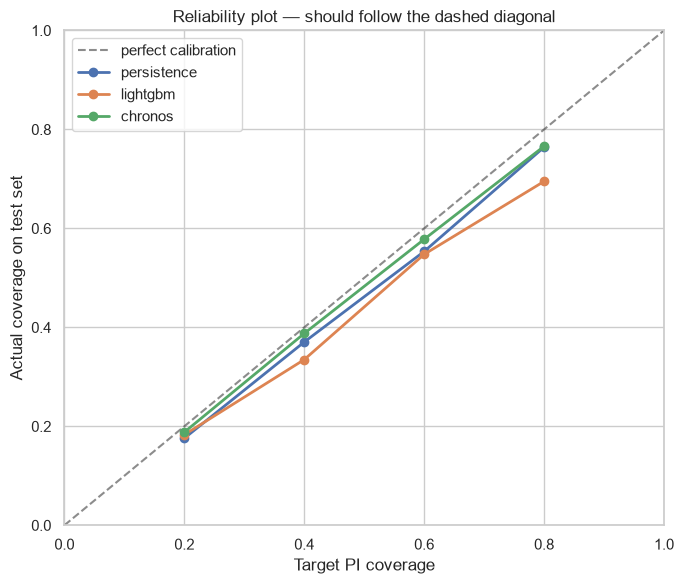

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='perfect calibration')

nominal_vals = [n for _, _, n in PIS]

for col in ['persistence', 'lightgbm', 'chronos']:
    empirical = [cov_df.loc[f'{int(n*100)}%', col] for n in nominal_vals]
    ax.plot(nominal_vals, empirical, 'o-', label=col, lw=2)

ax.set_xlabel('Target PI coverage')
ax.set_ylabel('Actual coverage on test set')
ax.set_title('Reliability plot — should follow the dashed diagonal')
ax.legend()
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

## Save calibration results

In [9]:
import json
out = Path('..') / 'results' / 'calibration.json'
out.parent.mkdir(exist_ok=True)
payload = {
    'coverage':  cov_df.to_dict(),
    'sharpness': sharp_df.to_dict(),
    'note': 'Coverage = fraction of actuals inside the PI. Sharpness = mean PI width as % of mean demand.',
}
out.write_text(json.dumps(payload, indent=2))
print(f'Wrote {out}')

Wrote ../results/calibration.json


## Takeaways for Day 8 (final scoreboard)

Calibration tells a different story than point accuracy. Three patterns to look for:

- **Persistence + val-set residuals** is usually surprisingly well-calibrated. Residual-based PIs are a strong default for any point forecaster — *if you have a representative val set*.
- **LightGBM quantile** can be sharper (narrower bands) but tends to be slightly over-confident — actual coverage below target.
- **Chronos zero-shot** is pre-trained, not calibrated to *your* data — coverage may drift from target in either direction.

Day 8 will combine point accuracy + calibration into one final comparison table for the README.